# 第六階段:聚焦「傳球路徑上的空間」

**最終目標**:做一個「傳球空間分析」工具,給教練或球探使用。

**本階段只做一件事**:對每位接球員,看從 **QB 到接球員**的這條傳球路徑(passing lane)上,有沒有防守員擋著。這比前面的指標更貼近**真實的傳球決策** —— QB 不是傳給全場最空的人,而是傳給「路徑乾淨、球送得進去」的人。

---

### 為什麼需要這個指標?(回顧前面的侷限)

- **第三階段 separation**:只看接球員頭上有沒有人盯,看不到「球飛過去的路上有沒有人攔」。
- **第五階段 Voronoi 控制區**:看整片場地歸屬,但進攻方永遠只佔一小塊,不適合直接判斷「這球傳不傳得進去」。
- **本階段 passing lane**:直接看**球要走的那條線**。這是三者裡最接近 QB 腦中決策的角度。

### 怎麼量化?「擋在路徑中間的最近防守員距離」

把 QB 到接球員畫一條線段,對每位防守員算「到這條線段的垂直距離」。距離越小代表越擋路。

**關鍵細節**:只算**真正擋在中間**的防守員 —— 也就是垂直投影落在線段上的人。QB 身邊或接球員身邊的防守員(投影落在線段端點外)不算擋路,否則會把「盯人的後衛」誤判成「擋傳球路線」。

## 步驟 0:載入工具與設定路徑

- **輸入**:無
- **輸出**:`pandas`、`numpy`、`matplotlib`、路徑設定
- **目的**:準備工具,跟前幾階段一樣。

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 中文字型(macOS 內建),避免圖上中文顯示成方框
plt.rcParams["font.sans-serif"] = ["PingFang TC", "Heiti TC", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

sys.path.append(str(Path.cwd().parent))
from config import DATA_DIR, SAMPLE_GAME_ID

SAMPLE_PLAY_ID = 137  # 延續前面階段的同一個 play
print("gameId:", SAMPLE_GAME_ID, "/ playId:", SAMPLE_PLAY_ID)

gameId: 2021090900 / playId: 137


## 步驟 1:重建傳球瞬間的場上狀態(含角色)

- **輸入**:`tracking`、`plays`、`players`、`pff`
- **輸出**:`frame`(傳球瞬間每位球員,附人名與角色)
- **目的**:讓本筆記本可獨立執行。這一階段只需要**傳球瞬間(pass_forward)那一格**:QB 在哪、接球員在哪、防守員在哪。

> 角色用 `pff_role`:`Pass`=QB(傳球者)、`Pass Route`=接球員、`Coverage`=防守員。

In [2]:
plays = pd.read_csv(DATA_DIR / "plays.csv")
players = pd.read_csv(DATA_DIR / "players.csv")
pff = pd.read_csv(DATA_DIR / "pffScoutingData.csv")
tracking = pd.read_csv(DATA_DIR / "tracking" / f"tracking_{SAMPLE_GAME_ID}.csv")

this_play = plays[(plays["gameId"] == SAMPLE_GAME_ID) & (plays["playId"] == SAMPLE_PLAY_ID)]

play_track = tracking[
    (tracking["gameId"] == SAMPLE_GAME_ID) & (tracking["playId"] == SAMPLE_PLAY_ID)
].copy()
pass_frame = play_track.loc[play_track["event"] == "pass_forward", "frameId"].iloc[0]

# 傳球瞬間、只要球員(排除球),接上角色與人名
roles = pff[
    (pff["gameId"] == SAMPLE_GAME_ID) & (pff["playId"] == SAMPLE_PLAY_ID)
][["nflId", "pff_role"]]
frame = (
    play_track[(play_track["frameId"] == pass_frame) & play_track["nflId"].notna()]
    .merge(players[["nflId", "displayName"]], on="nflId", how="left")
    .merge(roles, on="nflId", how="left")
)

print("傳球瞬間 frame:", pass_frame)
print("角色分佈:")
print(frame["pff_role"].value_counts())

傳球瞬間 frame: 32
角色分佈:
pff_role
Coverage      6
Pass Rush     5
Pass Block    5
Pass Route    5
Pass          1
Name: count, dtype: int64


## 步驟 2:分出 QB、接球員、防守員

- **輸入**:`frame`
- **輸出**:`qb`(QB 座標)、`receivers`、`defenders`
- **目的**:傳球路徑是「QB → 某接球員」,防守員是可能擋路的人,所以要把這三者分開。

In [3]:
qb_row = frame[frame["pff_role"] == "Pass"].iloc[0]
qb_xy = (qb_row["x"], qb_row["y"])
receivers = frame[frame["pff_role"] == "Pass Route"].copy()
defenders = frame[frame["pff_role"] == "Coverage"].copy()

print("QB:", qb_row["displayName"], "在", (round(qb_xy[0], 1), round(qb_xy[1], 1)))
print("接球員:", receivers["nflId"].nunique(), "位 / 防守員:", defenders["nflId"].nunique(), "位")

QB: Dak Prescott 在 (np.float64(116.5), np.float64(23.4))
接球員: 5 位 / 防守員: 6 位


## 步驟 3:核心幾何 —— 點到線段的距離

- **輸入**:一個點(防守員)、一條線段(QB → 接球員)
- **輸出**:垂直距離,以及投影是否落在線段上
- **目的**:這是本階段的數學核心。

**做法**:把防守員投影到 QB→接球員這條線上,看投影點落在哪:
- 投影參數 `t` 在 0~1 之間 → 真正**擋在中間**,回傳垂直距離。
- `t < 0` 或 `t > 1` → 在 QB 或接球員**身後/身邊**,不算擋路。

我們只在意「擋在中間」的防守員,所以會用這個 `t` 來過濾。

In [4]:
def point_to_segment(px, py, ax, ay, bx, by):
    """點 P 到線段 AB 的距離,以及投影參數 t。
    t in [0,1] 表示投影落在線段上(擋在中間)。"""
    vx, vy = bx - ax, by - ay          # 線段方向
    wx, wy = px - ax, py - ay          # A 指向 P
    seg_len2 = vx * vx + vy * vy
    if seg_len2 == 0:
        return np.hypot(px - ax, py - ay), 0.0
    t = (wx * vx + wy * vy) / seg_len2  # 投影比例
    t_clamped = max(0.0, min(1.0, t))
    cx, cy = ax + t_clamped * vx, ay + t_clamped * vy  # 線段上最近點
    return np.hypot(px - cx, py - cy), t


# 小驗證:防守員正好在 QB 與接球員正中間、偏一點點
d, t = point_to_segment(5, 1, 0, 0, 10, 0)
print("測試:點(5,1)到線段(0,0)-(10,0) → 距離", d, "投影t", t, "(應為 1.0 與 0.5)")

測試:點(5,1)到線段(0,0)-(10,0) → 距離 1.0 投影t 0.5 (應為 1.0 與 0.5)


## 步驟 4:算每位接球員的「傳球路徑風險」

- **輸入**:`qb_xy`、`receivers`、`defenders`
- **輸出**:DataFrame `lane`(每位接球員一列)
- **目的**:對每位接球員,算 QB→他這條路徑上,**擋在中間**的防守員裡最近的那個有多近。

**lane_min_dist** = 擋在中間的防守員到路徑的最小垂直距離。
- 數字**越小** = 有防守員越貼近傳球路線 = 這條路徑**越危險**。
- 若沒有任何防守員擋在中間,記為「無人擋路」(路徑乾淨)。

In [5]:
lane_rows = []
for _, r in receivers.iterrows():
    rx, ry = r["x"], r["y"]
    blockers = []  # (距離, 防守員名)
    for _, d in defenders.iterrows():
        dist, t = point_to_segment(d["x"], d["y"], qb_xy[0], qb_xy[1], rx, ry)
        if 0.0 <= t <= 1.0:            # 只算真正擋在中間的
            blockers.append((dist, d["displayName"]))

    if blockers:
        blockers.sort()
        lane_min, nearest = blockers[0]
        n_block = len(blockers)
    else:
        lane_min, nearest, n_block = np.nan, "(無人擋路)", 0

    lane_rows.append({
        "receiver": r["displayName"],
        "lane_min_dist": round(lane_min, 2) if n_block else np.nan,
        "nearest_blocker": nearest,
        "blockers_in_lane": n_block,
        "qb_to_receiver_yd": round(np.hypot(rx - qb_xy[0], ry - qb_xy[1]), 1),
    })

lane = pd.DataFrame(lane_rows)
# 路徑越乾淨(擋路者越遠 / 沒人擋)排越前面;沒人擋的視為最乾淨
lane = lane.sort_values("lane_min_dist", ascending=False, na_position="first")
print("=== 傳球瞬間,每位接球員的傳球路徑狀況 ===")
print(lane.to_string(index=False))

=== 傳球瞬間,每位接球員的傳球路徑狀況 ===
       receiver  lane_min_dist nearest_blocker  blockers_in_lane  qb_to_receiver_yd
 Dalton Schultz          18.70   Lavonte David                 1               16.7
    CeeDee Lamb           5.86   Lavonte David                 3               21.5
   Blake Jarwin           2.23 Shaquil Barrett                 3               24.2
Ezekiel Elliott           2.21 Shaquil Barrett                 4               27.7
   Amari Cooper           0.76   Lavonte David                 4               22.4


## 步驟 5:對照實際傳球目標

- **輸入**:`lane`、`this_play` 的文字描述
- **輸出**:比較「路徑最乾淨的人」vs「實際傳球目標」
- **目的**:用這個 play 檢驗指標說不說得通。注意:我們**只是對照**,不評論 QB 決策對錯。

In [6]:
print("play 文字描述:")
print(this_play["playDescription"].iloc[0])
print()

cleanest = lane.iloc[0]
if cleanest["blockers_in_lane"] == 0:
    print(f"路徑最乾淨的接球員:{cleanest['receiver']}(路徑上無人擋)")
else:
    print(f"路徑最乾淨的接球員:{cleanest['receiver']}"
          f"(最近擋路者 {cleanest['nearest_blocker']} 距路徑 {cleanest['lane_min_dist']} 碼)")

print()
print("提醒:這是深傳 play(deep left)。QB 傳的是球飛到接球員『未來位置』,")
print("所以『QB→接球員當下位置的直線』上有人擋,不代表實際傳不進去 ——")
print("這正是本指標的已知侷限,下一階段可用球的飛行軌跡修正。")

play 文字描述:
(13:18) (Shotgun) D.Prescott pass deep left to A.Cooper pushed ob at DAL 30 for 28 yards (A.Winfield).

路徑最乾淨的接球員:Dalton Schultz(最近擋路者 Lavonte David 距路徑 18.7 碼)

提醒:這是深傳 play(deep left)。QB 傳的是球飛到接球員『未來位置』,
所以『QB→接球員當下位置的直線』上有人擋,不代表實際傳不進去 ——
這正是本指標的已知侷限,下一階段可用球的飛行軌跡修正。


## 步驟 6:畫出傳球路徑圖

- **輸入**:`qb_xy`、`receivers`、`defenders`、`lane`
- **輸出**:一張球場圖,畫出每條 QB→接球員的路徑與防守員
- **目的**:把「哪條路徑乾淨、哪條被擋」直接畫出來。路徑用虛線,擋路者越近的路徑標越紅。

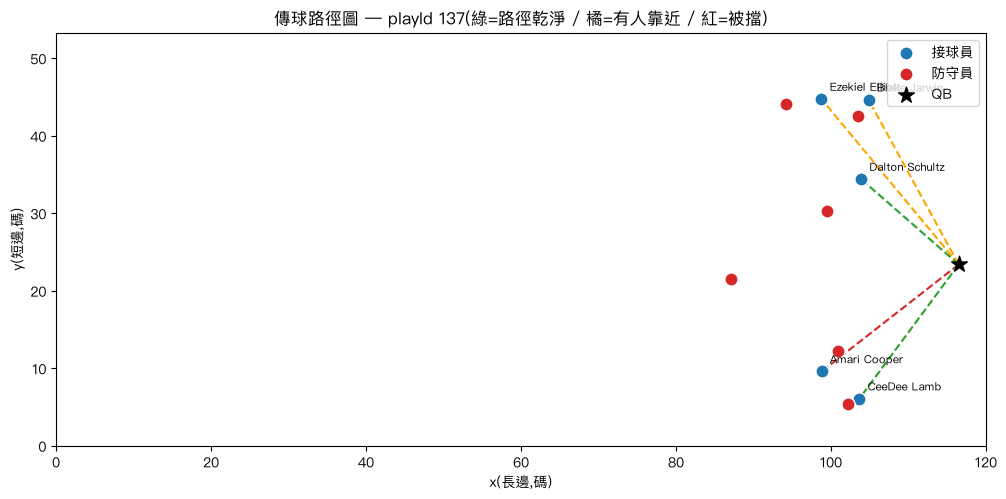

In [7]:
lane_by_name = lane.set_index("receiver")

fig, ax = plt.subplots(figsize=(12, 6))

# 傳球路徑(QB -> 每位接球員)
for _, r in receivers.iterrows():
    info = lane_by_name.loc[r["displayName"]]
    d = info["lane_min_dist"]
    # 擋路者越近越紅,無人擋或較遠偏綠
    color = "tab:green" if (pd.isna(d) or d >= 3) else ("orange" if d >= 1.5 else "tab:red")
    ax.plot([qb_xy[0], r["x"]], [qb_xy[1], r["y"]], linestyle="--",
            color=color, linewidth=1.5, zorder=2)

# 球員
ax.scatter(receivers["x"], receivers["y"], c="tab:blue", s=90,
           edgecolor="white", label="接球員", zorder=3)
ax.scatter(defenders["x"], defenders["y"], c="tab:red", s=90,
           edgecolor="white", label="防守員", zorder=3)
ax.scatter([qb_xy[0]], [qb_xy[1]], c="black", s=140, marker="*",
           label="QB", zorder=4)

# 接球員名字
for _, r in receivers.iterrows():
    ax.annotate(r["displayName"], (r["x"], r["y"]),
                textcoords="offset points", xytext=(6, 6), fontsize=8)

ax.set_xlim(0, 120)
ax.set_ylim(0, 53.3)
ax.set_xlabel("x(長邊,碼)")
ax.set_ylabel("y(短邊,碼)")
ax.set_title(f"傳球路徑圖 — playId {SAMPLE_PLAY_ID}(綠=路徑乾淨 / 橘=有人靠近 / 紅=被擋)")
ax.legend(loc="upper right")
ax.set_aspect("equal")
plt.show()

## 本階段完成了什麼

- 把視角從「全場空間」收斂到**球真正要走的那條線**:QB → 接球員的傳球路徑。
- 用「點到線段距離 + 投影參數」只挑出**真正擋在中間**的防守員,避開把盯人後衛誤判成擋路。
- 算出每位接球員的傳球路徑風險(最近擋路者距離 / 是否無人擋),並畫成**傳球路徑圖**(綠/橘/紅)。
- 誠實標出指標侷限:深傳是傳到接球員的「未來位置」,直線路徑指標會低估成功機會。

**為什麼這是三個指標裡最貼近決策的?** separation 看單點、Voronoi 看全場,而 passing lane 直接看球要飛過的通道 —— 最接近 QB「這球傳不傳得進去」的判斷。

**下一階段(等你確認理解後再開始)**:
1. **用球的飛行軌跡修正路徑**:tracking 裡有球的座標,可改用「球實際飛到的落點」當路徑終點,解決深傳被低估的問題。
2. **把三個指標整合成一張 play 卡**:同一個 play 同時呈現 separation、控制區、passing lane,做成給教練看的單頁摘要(往「分析工具」的產品形態邁進)。